<a href="https://colab.research.google.com/github/Goal48/Gridlock-Hackathon---Traffic-Demand-Prediction/blob/main/Traffic_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
df = pd.read_csv("/content/train.csv")
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [4]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


In [5]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['geohash', 'timestamp', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']


In [6]:
for col in cat_cols :
  df[col] = df[col].fillna('Missing')

In [ ]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,0
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


The value counts of RoadType -----------
RoadType
Residential    69230
Street          3909
Highway         3560
Missing          600
Name: count, dtype: int64
--------------------------


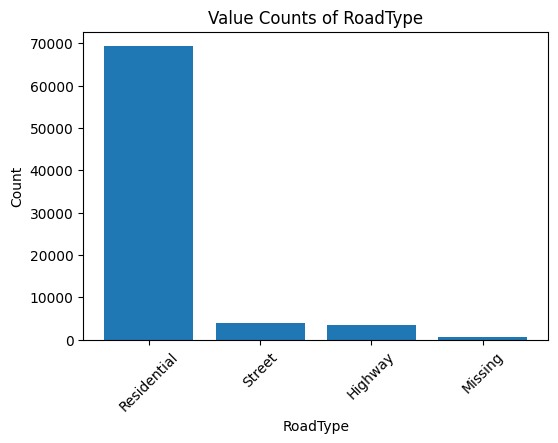

The value counts of LargeVehicles -----------
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64
--------------------------


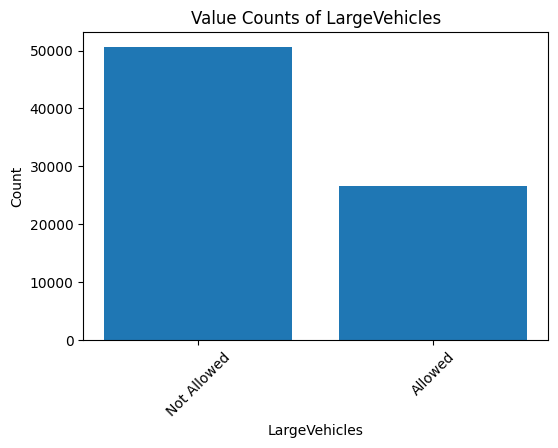

The value counts of Landmarks -----------
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64
--------------------------


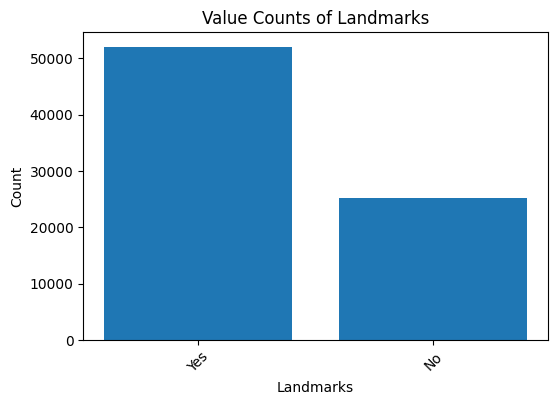

The value counts of Weather -----------
Weather
Sunny      27717
Rainy      20824
Foggy      20243
Snowy       7718
Missing      797
Name: count, dtype: int64
--------------------------


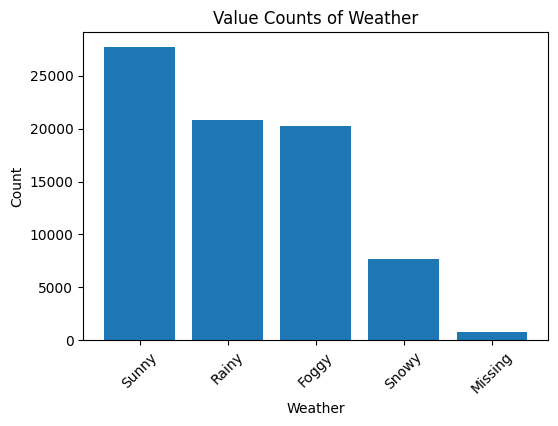

In [ ]:
## Value counts
def Value_counts(df, val_col):
    for col in val_col:
        print(f"The value counts of {col} -----------")

        counts = df[col].value_counts()
        print(counts)
        print("--------------------------")

        plt.figure(figsize=(6, 4))
        plt.bar(counts.index.astype(str), counts.values)
        plt.title(f"Value Counts of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

val_col = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
Value_counts(df, val_col)

In [ ]:
df['hour'] = pd.to_datetime(
    df['timestamp'],
    format='%H:%M'
).dt.hour

df['minute'] = pd.to_datetime(
    df['timestamp'],
    format='%H:%M'
).dt.minute

df['time_minutes'] = df['hour']*60 + df['minute']

df['time_sin'] = np.sin(
    2*np.pi*df['time_minutes']/1440
)

df['time_cos'] = np.cos(
    2*np.pi*df['time_minutes']/1440
)

In [ ]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,time_minutes,time_sin,time_cos
0,0,qp02z1,48,0:0,0.048804,Missing,1,Not Allowed,No,NaN,Missing,0,0,0,0.0,1.0
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0,0.0,1.0
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0,0.0,1.0
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,0,0,0,0.0,1.0
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0,0.0,1.0


In [ ]:
df.groupby('geohash')['demand'].agg(['mean','count'])

,mean,count
geohash,,
qp02yc,0.018498,12
qp02yf,0.029433,1
qp02yy,0.002902,2
qp02yz,0.036564,30
qp02z1,0.040048,33
...,...,...
qp0dn4,0.007811,3
qp0dn5,0.003714,7
qp0dnh,0.001401,2


In [7]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
import catboost
from catboost import CatBoostRegressor

In [ ]:
df.drop('timestamp', axis=1, inplace=True)

In [ ]:
X = df.drop(['Index','demand'],axis=1)
y = df['demand']

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.dtypes)

geohash           object
day                int64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
hour               int32
minute             int32
time_minutes       int32
time_sin         float64
time_cos         float64
dtype: object


In [ ]:
cat_features = [
    'geohash',
    'RoadType',
    'LargeVehicles',
    'Landmarks',
    'Weather'
]

model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE'
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.1390085	total: 103ms	remaining: 3m 25s
1:	learn: 0.1359592	total: 162ms	remaining: 2m 41s
2:	learn: 0.1330179	total: 199ms	remaining: 2m 12s
3:	learn: 0.1301813	total: 238ms	remaining: 1m 58s
4:	learn: 0.1274629	total: 260ms	remaining: 1m 43s
5:	learn: 0.1248625	total: 301ms	remaining: 1m 40s
6:	learn: 0.1223572	total: 331ms	remaining: 1m 34s
7:	learn: 0.1199539	total: 346ms	remaining: 1m 26s
8:	learn: 0.1176455	total: 398ms	remaining: 1m 28s
9:	learn: 0.1154212	total: 449ms	remaining: 1m 29s
10:	learn: 0.1129752	total: 500ms	remaining: 1m 30s
11:	learn: 0.1105681	total: 541ms	remaining: 1m 29s
12:	learn: 0.1082740	total: 584ms	remaining: 1m 29s
13:	learn: 0.1060613	total: 623ms	remaining: 1m 28s
14:	learn: 0.1039179	total: 660ms	remaining: 1m 27s
15:	learn: 0.1018458	total: 697ms	remaining: 1m 26s
16:	learn: 0.0998861	total: 740ms	remaining: 1m 26s
17:	learn: 0.0979655	total: 785ms	remaining: 1m 26s
18:	learn: 0.0961345	total: 833ms	remaining: 1m 26s
19:	learn: 0.0943818	t

CatBoostRegressor(depth=8, iterations=2000, learning_rate=0.03, loss_function='RMSE')

In [ ]:
preds = model.predict(X_valid)

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_valid, preds))
print("RMSE:", rmse)

RMSE: 0.03417619266456547


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_valid, preds)
print("MAE:", mae)

MAE: 0.021867006016631267


In [ ]:
from sklearn.metrics import r2_score

preds = model.predict(X_valid)

r2 = r2_score(y_valid, preds)
score = max(0, 100 * r2)

print("R2:", r2)

R2: 0.9422761445148341


In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.0440270	test: 0.0449121	best: 0.0449121 (0)	total: 187ms	remaining: 15m 33s
200:	learn: 0.9063469	test: 0.9071744	best: 0.9071744 (200)	total: 14.6s	remaining: 5m 48s
400:	learn: 0.9233752	test: 0.9214732	best: 0.9214732 (400)	total: 26.5s	remaining: 5m 3s
600:	learn: 0.9308872	test: 0.9270642	best: 0.9270642 (600)	total: 37.4s	remaining: 4m 34s
800:	learn: 0.9369412	test: 0.9313955	best: 0.9313955 (800)	total: 49.5s	remaining: 4m 19s
1000:	learn: 0.9415514	test: 0.9344701	best: 0.9344701 (1000)	total: 1m 1s	remaining: 4m 5s
1200:	learn: 0.9452066	test: 0.9366795	best: 0.9366795 (1200)	total: 1m 13s	remaining: 3m 54s
1400:	learn: 0.9480000	test: 0.9382829	best: 0.9382829 (1400)	total: 1m 26s	remaining: 3m 42s
1600:	learn: 0.9503269	test: 0.9394381	best: 0.9394381 (1600)	total: 1m 38s	remaining: 3m 29s
1800:	learn: 0.9526350	test: 0.9406787	best: 0.9406787 (1800)	total: 1m 51s	remaining: 3m 18s
2000:	learn: 0.9544200	test: 0.9416334	best: 0.9416334 (2000)	total: 2m 4s	remain

CatBoostRegressor(depth=8, eval_metric='R2', iterations=5000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [ ]:
imp = model.get_feature_importance()

for c, i in sorted(
    zip(X_train.columns, imp),
    key=lambda x: x[1],
    reverse=True
):
    print(c, round(i, 2))

RoadType 40.05
geohash 22.15
LargeVehicles 9.74
NumberofLanes 9.04
time_cos 4.93
time_sin 4.38
time_minutes 3.24
hour 1.75
Weather 1.51
day 1.47
Temperature 1.13
Landmarks 0.34
minute 0.28


In [ ]:
preds = model.predict(X_valid)

from sklearn.metrics import r2_score
print(r2_score(y_valid, preds))

0.947217390378861


In [9]:
test_df = pd.read_csv("/content/test.csv")

In [10]:
cat_features = [
    'geohash',
    'RoadType',
    'LargeVehicles',
    'Landmarks',
    'Weather'
]

for col in cat_features:
    test_df[col] = test_df[col].astype(str)

In [11]:
test_df['hour'] = pd.to_datetime(
    test_df['timestamp'],
    format='%H:%M'
).dt.hour

test_df['minute'] = pd.to_datetime(
    test_df['timestamp'],
    format='%H:%M'
).dt.minute

test_df['time_minutes'] = test_df['hour']*60 + test_df['minute']

test_df['time_sin'] = np.sin(
    2*np.pi*test_df['time_minutes']/1440
)

test_df['time_cos'] = np.cos(
    2*np.pi*test_df['time_minutes']/1440
)

test_df.drop('timestamp', axis=1, inplace=True)

In [12]:
print(set(X_train.columns) - set(test_df.columns))
print(set(test_df.columns) - set(X_train.columns))

{'geo_weather', 'temp_bin', 'geo_road', 'is_evening_peak', 'is_morning_peak'}
set()


In [13]:
test_ids = test_df['Index']


In [14]:
test_df = test_df.drop('Index', axis=1)

In [15]:
test_df = test_df[X_train.columns]

KeyError: "['Index', 'is_morning_peak', 'is_evening_peak', 'geo_weather', 'geo_road', 'temp_bin'] not in index"

In [16]:
print(X_train.columns.equals(test_df.columns))

False


In [17]:
test_preds = model.predict(test_df)

CatBoostError: Invalid cat_features[6] = 16 value: index must be < 13.

In [ ]:
submission = pd.DataFrame({
    'Index': test_ids,
    'demand': test_preds
})

submission.to_csv('sample_submission.csv', index=False)

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor

# =====================================================
# MISSING VALUES
# =====================================================

cat_cols = [
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks'
]

for col in cat_cols:
    df[col] = df[col].fillna('Missing')

# =====================================================
# TIME FEATURES
# =====================================================

df['hour'] = pd.to_datetime(
    df['timestamp'],
    format='%H:%M'
).dt.hour

df['minute'] = pd.to_datetime(
    df['timestamp'],
    format='%H:%M'
).dt.minute

df['time_minutes'] = (
    df['hour'] * 60 +
    df['minute']
)

df['time_sin'] = np.sin(
    2 * np.pi * df['time_minutes'] / 1440
)

df['time_cos'] = np.cos(
    2 * np.pi * df['time_minutes'] / 1440
)

# =====================================================
# DAY AS CATEGORY
# =====================================================

df['day'] = df['day'].astype(str)

# =====================================================
# PEAK HOUR FEATURES
# =====================================================

df['is_morning_peak'] = (
    df['hour'].between(7,10)
).astype(int)

df['is_evening_peak'] = (
    df['hour'].between(17,20)
).astype(int)

# =====================================================
# GEOHASH INTERACTIONS
# =====================================================

df['geo_weather'] = (
    df['geohash'].astype(str) + "_" +
    df['Weather'].astype(str)
)

df['geo_road'] = (
    df['geohash'].astype(str) + "_" +
    df['RoadType'].astype(str)
)

# =====================================================
# TEMPERATURE BIN
# =====================================================

df['temp_bin'] = pd.cut(
    df['Temperature'],
    bins=[-100,10,20,30,40,100],
    labels=[
        'very_cold',
        'cold',
        'mild',
        'warm',
        'hot'
    ]
)

df['temp_bin'] = df['temp_bin'].astype(str)

# =====================================================
# DROP UNUSED
# =====================================================

df.drop(
    ['timestamp'],
    axis=1,
    inplace=True
)

# =====================================================
# FEATURES
# =====================================================

target = 'demand'

X = df.drop(target, axis=1)
y = df[target]

# =====================================================
# CAT FEATURES
# =====================================================

cat_features = [
    'geohash',
    'day',
    'RoadType',
    'LargeVehicles',
    'Landmarks',
    'Weather',
    'geo_weather',
    'geo_road',
    'temp_bin'
]

# =====================================================
# SPLIT
# =====================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODEL
# =====================================================

model = CatBoostRegressor(
    iterations=8000,
    learning_rate=0.02,
    depth=10,
    l2_leaf_reg=5,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

# =====================================================
# VALIDATION SCORE
# =====================================================

preds = model.predict(X_valid)

r2 = r2_score(y_valid, preds)

print("R2 =", r2)
print("Competition Score =", 100 * r2)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
}).sort_values(
    'importance',
    ascending=False
)

print(imp.head(20))

0:	learn: 0.0294835	test: 0.0300872	best: 0.0300872 (0)	total: 318ms	remaining: 42m 24s
200:	learn: 0.9076528	test: 0.9074772	best: 0.9074772 (200)	total: 36.7s	remaining: 23m 43s
400:	learn: 0.9253340	test: 0.9224610	best: 0.9224610 (400)	total: 1m 14s	remaining: 23m 32s
600:	learn: 0.9329665	test: 0.9284997	best: 0.9284997 (600)	total: 1m 50s	remaining: 22m 36s
800:	learn: 0.9378976	test: 0.9317291	best: 0.9317291 (799)	total: 2m 26s	remaining: 21m 56s
1000:	learn: 0.9434605	test: 0.9358326	best: 0.9358326 (1000)	total: 3m 7s	remaining: 21m 49s
1200:	learn: 0.9471331	test: 0.9380862	best: 0.9380862 (1200)	total: 3m 49s	remaining: 21m 37s
1400:	learn: 0.9501301	test: 0.9399169	best: 0.9399169 (1400)	total: 4m 31s	remaining: 21m 20s
1600:	learn: 0.9528701	test: 0.9412562	best: 0.9412564 (1598)	total: 5m 20s	remaining: 21m 20s
1800:	learn: 0.9556025	test: 0.9425050	best: 0.9425050 (1800)	total: 6m 4s	remaining: 20m 53s
2000:	learn: 0.9579432	test: 0.9433887	best: 0.9433887 (2000)	total:

In [20]:
df = df.drop('Index', axis=1)

X = df.drop('demand', axis=1)
y = df['demand']

In [21]:
test_df = pd.read_csv("test.csv")
test_ids = test_df["Index"]

# Fill missing values

cat_cols = [
    'RoadType',
    'Weather',
    'LargeVehicles',
    'Landmarks'
]

for col in cat_cols:
    test_df[col] = test_df[col].fillna('Missing')


# Time features

test_df['hour'] = pd.to_datetime(
    test_df['timestamp'],
    format='%H:%M'
).dt.hour

test_df['minute'] = pd.to_datetime(
    test_df['timestamp'],
    format='%H:%M'
).dt.minute

test_df['time_minutes'] = (
    test_df['hour'] * 60 +
    test_df['minute']
)

test_df['time_sin'] = np.sin(
    2*np.pi*test_df['time_minutes']/1440
)

test_df['time_cos'] = np.cos(
    2*np.pi*test_df['time_minutes']/1440
)

# Same engineered features

test_df['day'] = test_df['day'].astype(str)

test_df['is_morning_peak'] = (
    test_df['hour'].between(7,10)
).astype(int)

test_df['is_evening_peak'] = (
    test_df['hour'].between(17,20)
).astype(int)

test_df['geo_weather'] = (
    test_df['geohash'].astype(str) + "_" +
    test_df['Weather'].astype(str)
)

test_df['geo_road'] = (
    test_df['geohash'].astype(str) + "_" +
    test_df['RoadType'].astype(str)
)

test_df['temp_bin'] = pd.cut(
    test_df['Temperature'],
    bins=[-100,10,20,30,40,100],
    labels=[
        'very_cold',
        'cold',
        'mild',
        'warm',
        'hot'
    ]
)

test_df['temp_bin'] = test_df['temp_bin'].astype(str)

test_df = test_df.drop(
    columns=['Index', 'timestamp'],
    errors='ignore'
)

test_df = test_df[X.columns]

X = df.drop('demand', axis=1)

X = df.drop('demand', axis=1)

model.fit(
    X,
    y,
    cat_features=cat_features
)

submission = pd.DataFrame({
    "Index": test_ids,
    "demand": test_preds
})

submission.to_csv(
    "sample_submission.csv",
    index=False
)

print(submission.head())

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=15]="qp02z1_Missing": Cannot convert 'qp02z1_Missing' to float

In [19]:
print(X.columns.tolist())

['Index', 'geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'time_minutes', 'time_sin', 'time_cos', 'is_morning_peak', 'is_evening_peak', 'geo_weather', 'geo_road', 'temp_bin']
